# Notebook 01: Empirical Stylized Facts

This notebook characterizes the three canonical stylized facts of financial returns using SPY daily data:

1. **Heavy-tailed (leptokurtic) distributions** -- excess kurtosis significantly greater than zero, indicating that extreme moves occur more frequently than a Gaussian model predicts.
2. **Negligible linear autocorrelation** in raw returns -- consistent with weak-form efficiency; the ACF of $G_t$ is statistically indistinguishable from zero at most lags.
3. **Persistent volatility clustering** -- the ACF of $|G_t|$ decays slowly, confirming that large moves tend to follow large moves regardless of sign.

These facts motivate the use of a continuous Hidden Markov Model (no jump mechanisms) whose latent regimes can capture heavy tails and volatility persistence that a single Gaussian cannot.

### Outputs
- **Table 1**: Descriptive statistics and stylized-facts tests (IS and OoS)
- **Figure 1**: Four-panel stylized facts visualization (distribution, Q-Q plot, returns ACF, |returns| ACF)
- **OoS verification**: Quick distribution and ACF plots for the 2025 holdout window

## Setup

In [1]:
include("../Include.jl");

## Configuration

Tune the parameters below to explore different assets, risk-free rates, or ACF horizons.

In [2]:
# --- USER-TUNABLE PARAMETERS ---
risk_free_rate = 0.0;       # risk-free rate (set to 0 to isolate volatility patterns)
Δt = 1/252;                 # daily time step in years
ticker = "SPY";             # primary validation asset
L = 252;                    # ACF max lag (1 trading year)

## Load In-Sample Data (2014--2024)

In [3]:
# --- LOAD IN-SAMPLE DATA ---
train_dataset = MyPortfolioDataSet() |> x -> x["dataset"];
maximum_number_trading_days = nrow(train_dataset["AAPL"]);

# Filter to tickers with complete history
dataset = Dict{String,DataFrame}();
for (t, data) ∈ train_dataset
    if nrow(data) == maximum_number_trading_days
        dataset[t] = data;
    end
end

list_of_all_tickers = keys(dataset) |> collect |> sort;
println("In-sample: $(length(list_of_all_tickers)) tickers, $(maximum_number_trading_days) trading days each");

# Compute excess log growth rates
R_is = log_growth_matrix(dataset, ticker; Δt=Δt, risk_free_rate=risk_free_rate);
println("IS returns: T = $(length(R_is)) observations");

In-sample: 424 tickers, 2767 trading days each
IS returns: T = 2766 observations


## Load Out-of-Sample Data (2025)

In [4]:
# --- LOAD OUT-OF-SAMPLE DATA ---
oos_dataset_raw = MyOutOfSamplePortfolioDataSet() |> x -> x["dataset"];
oos_max_days = nrow(first(values(oos_dataset_raw)));

oos_dataset = Dict{String,DataFrame}();
for (t, data) ∈ oos_dataset_raw
    if nrow(data) == oos_max_days
        oos_dataset[t] = data;
    end
end

# Compute excess log growth rates
R_oos = log_growth_matrix(oos_dataset, ticker; Δt=Δt, risk_free_rate=risk_free_rate);
println("Out-of-sample: $(length(oos_dataset)) tickers, $(oos_max_days) trading days each");
println("OoS returns: T = $(length(R_oos)) observations");

Out-of-sample: 476 tickers, 220 trading days each
OoS returns: T = 219 observations


## Table 1: Descriptive Statistics and Stylized-Facts Tests

For each sample we report:
- **Mean, Std** -- annualized excess growth rate moments
- **Skewness, Excess Kurtosis** -- shape diagnostics (kurtosis >> 0 indicates heavy tails)
- **Jarque-Bera** -- tests normality; rejects if heavy tails or skewness present
- **Ljung-Box on $G_t$** -- tests autocorrelation in raw returns (should fail to reject or weakly reject)
- **Ljung-Box on $|G_t|$** -- tests volatility clustering (should reject strongly)

In [5]:
# --- TABLE 1: DESCRIPTIVE STATISTICS ---
function compute_descriptive_stats(R::Vector{Float64}, label::String;
        lb_lags::Int=20)

    n = length(R);
    μ = mean(R);
    σ = std(R);
    z = (R .- μ) ./ σ;
    skew = sum(z .^ 3) / n;
    kurt_excess = sum(z .^ 4) / n - 3.0;

    # Jarque-Bera statistic
    jb_stat = (n / 6) * (skew^2 + (kurt_excess^2) / 4);

    # Ljung-Box on raw returns
    acf_raw = autocor(R, 1:lb_lags);
    lb_raw = n * (n + 2) * sum(acf_raw .^ 2 ./ (n .- (1:lb_lags)));

    # Ljung-Box on |returns| (volatility clustering)
    acf_abs = autocor(abs.(R), 1:lb_lags);
    lb_abs = n * (n + 2) * sum(acf_abs .^ 2 ./ (n .- (1:lb_lags)));

    println("\n--- $label (T = $n) ---");
    println("Mean (annualized, %):     $(round(μ, digits=2))");
    println("Std Dev (annualized, %):  $(round(σ, digits=2))");
    println("Skewness:                 $(round(skew, digits=3))");
    println("Excess Kurtosis:          $(round(kurt_excess, digits=3))");
    println("JB statistic:             $(round(jb_stat, digits=1)) (critical value ≈ 5.99 at α=0.05)");
    println("LB on Gₜ  (lag $lb_lags):       $(round(lb_raw, digits=1)) (critical value ≈ 31.4 at α=0.05)");
    println("LB on |Gₜ| (lag $lb_lags):      $(round(lb_abs, digits=1)) (critical value ≈ 31.4 at α=0.05)");

    return (mean=μ, std=σ, skewness=skew, excess_kurtosis=kurt_excess,
            jb=jb_stat, lb_raw=lb_raw, lb_abs=lb_abs);
end;

stats_is  = compute_descriptive_stats(R_is,  "In-Sample (2014-2024)");
stats_oos = compute_descriptive_stats(R_oos, "Out-of-Sample (2025)");


--- In-Sample (2014-2024) (T = 2766) ---
Mean (annualized, %):     0.11
Std Dev (annualized, %):  2.14
Skewness:                 -0.753
Excess Kurtosis:          7.707
JB statistic:             7107.4 (critical value ≈ 5.99 at α=0.05)
LB on Gₜ  (lag 20):       145.3 (critical value ≈ 31.4 at α=0.05)
LB on |Gₜ| (lag 20):      3057.9 (critical value ≈ 31.4 at α=0.05)

--- Out-of-Sample (2025) (T = 219) ---
Mean (annualized, %):     0.13
Std Dev (annualized, %):  2.31
Skewness:                 -1.071
Excess Kurtosis:          6.242
JB statistic:             397.4 (critical value ≈ 5.99 at α=0.05)
LB on Gₜ  (lag 20):       28.1 (critical value ≈ 31.4 at α=0.05)
LB on |Gₜ| (lag 20):      150.4 (critical value ≈ 31.4 at α=0.05)


## Figure 1: Stylized Facts of SPY

Four-panel figure:
- **(a)** Marginal distribution histogram with Gaussian and Laplace fits (percentile-based x-limits)
- **(b)** Normal Q-Q plot (heavy tails visible as departures from the 45-degree line)
- **(c)** ACF of raw returns $G_t$ with 99% confidence interval
- **(d)** ACF of $|G_t|$ showing slow decay (volatility clustering)

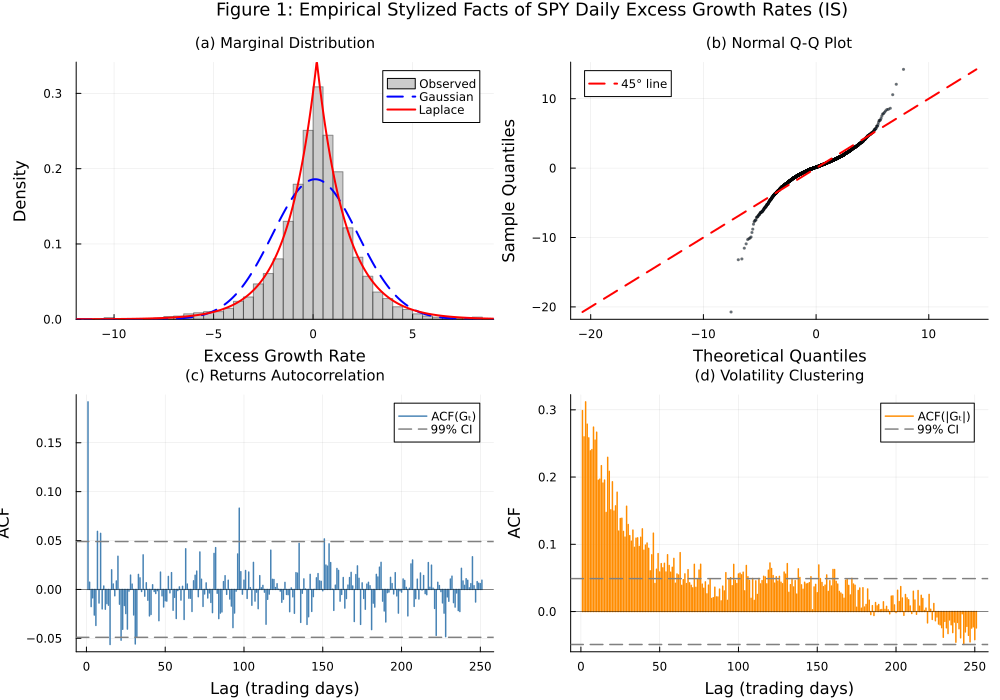

LoadError: SystemError: opening file "/Users/abdulrahmanalswaidan/Desktop/Project-Repos/HMM-withJumps-WIP/figs/Fig-SPY-Stylized-Facts-IS.svg": No such file or directory

In [6]:
# --- FIGURE 1: STYLIZED FACTS (4-panel, 2x2) ---

# Fit Gaussian
μ_gauss = mean(R_is);
σ_gauss = std(R_is);
d_gauss = Normal(μ_gauss, σ_gauss);

# Fit Laplace via MLE: location = median, scale = mean(|x - median|)
μ_lap = median(R_is);
b_lap = mean(abs.(R_is .- μ_lap));
d_laplace = Laplace(μ_lap, b_lap);

# Percentile-based x-limits for clean visualization
xl_lo = quantile(R_is, 0.001);
xl_hi = quantile(R_is, 0.999);
x_grid = range(xl_lo, xl_hi, length=1000);

# Panel (a): Marginal distribution
p1 = histogram(R_is, normalize=true, bins=150, alpha=0.4, color=:gray, label="Observed",
    title="(a) Marginal Distribution", titlefontsize=10,
    xlabel="Excess Growth Rate", ylabel="Density");
plot!(p1, x_grid, pdf.(d_gauss, x_grid), lw=2, color=:blue, ls=:dash, label="Gaussian");
plot!(p1, x_grid, pdf.(d_laplace, x_grid), lw=2, color=:red, label="Laplace");
xlims!(p1, xl_lo, xl_hi);

# Panel (b): Normal Q-Q plot
sorted_R = sort(R_is);
n_obs = length(sorted_R);
theoretical_quantiles = [quantile(d_gauss, (i - 0.5) / n_obs) for i in 1:n_obs];

p2 = scatter(theoretical_quantiles, sorted_R, ms=1, alpha=0.5, color=:steelblue, label="",
    title="(b) Normal Q-Q Plot", titlefontsize=10,
    xlabel="Theoretical Quantiles", ylabel="Sample Quantiles");
qq_lo = min(minimum(theoretical_quantiles), minimum(sorted_R));
qq_hi = max(maximum(theoretical_quantiles), maximum(sorted_R));
plot!(p2, [qq_lo, qq_hi], [qq_lo, qq_hi], lw=2, color=:red, ls=:dash, label="45° line");

# Panel (c): ACF of raw returns
τ = 1:(L-1);
ci_99 = 2.576 / sqrt(n_obs);  # 99% CI under white-noise null

acf_raw = autocor(R_is, τ);
p3 = plot(τ, acf_raw, linetype=:sticks, lw=1.5, color=:steelblue, label="ACF(Gₜ)",
    title="(c) Returns Autocorrelation", titlefontsize=10,
    xlabel="Lag (trading days)", ylabel="ACF");
hline!(p3, [ci_99, -ci_99], lw=1.5, color=:gray, ls=:dash, label="99% CI");
hline!(p3, [0.0], lw=0.5, color=:black, label="");

# Panel (d): ACF of |returns|
acf_abs = autocor(abs.(R_is), τ);
p4 = plot(τ, acf_abs, linetype=:sticks, lw=1.5, color=:darkorange, label="ACF(|Gₜ|)",
    title="(d) Volatility Clustering", titlefontsize=10,
    xlabel="Lag (trading days)", ylabel="ACF");
hline!(p4, [ci_99, -ci_99], lw=1.5, color=:gray, ls=:dash, label="99% CI");
hline!(p4, [0.0], lw=0.5, color=:black, label="");

# Combine into 2x2 layout
fig1 = plot(p1, p2, p3, p4, layout=(2,2), size=(1000, 700),
    plot_title="Figure 1: Empirical Stylized Facts of $(ticker) Daily Excess Growth Rates (IS)",
    plot_titlefontsize=12);
display(fig1);

# Save to figs/
savefig(fig1, joinpath(_PATH_TO_FIGURES, "Fig-$(ticker)-Stylized-Facts-IS.svg"));
savefig(fig1, joinpath(_PATH_TO_FIGURES, "Fig-$(ticker)-Stylized-Facts-IS.pdf"));
println("Saved Figure 1 to figs/");

## Out-of-Sample Verification (2025 Holdout)

Verify that the same stylized facts hold in the OoS window: heavy tails, negligible raw-return ACF, persistent absolute-return ACF.

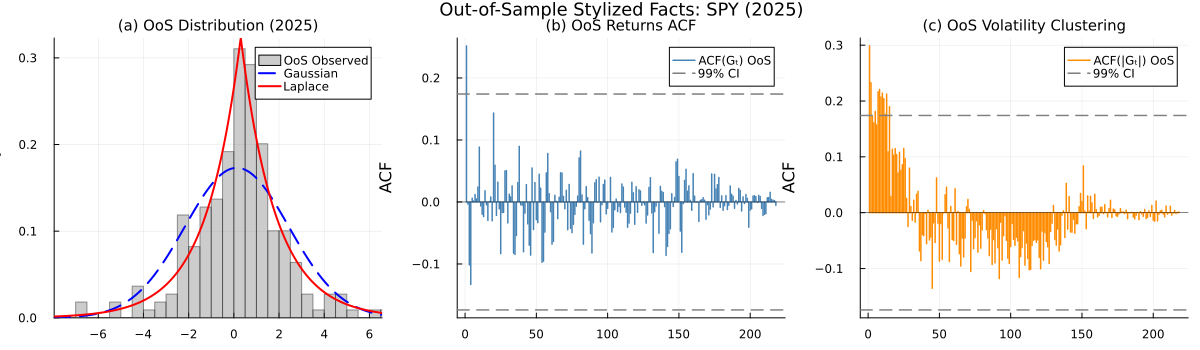

LoadError: SystemError: opening file "/Users/abdulrahmanalswaidan/Desktop/Project-Repos/HMM-withJumps-WIP/figs/Fig-SPY-Stylized-Facts-OoS.svg": No such file or directory

In [7]:
# --- OOS STYLIZED FACTS VERIFICATION ---
n_oos = length(R_oos);
τ_oos = 1:min(L-1, n_oos-1);
ci_oos = 2.576 / sqrt(n_oos);

# Fit distributions to OoS
d_gauss_oos = Normal(mean(R_oos), std(R_oos));
μ_lap_oos = median(R_oos);
b_lap_oos = mean(abs.(R_oos .- μ_lap_oos));
d_laplace_oos = Laplace(μ_lap_oos, b_lap_oos);

xl_lo_oos = quantile(R_oos, 0.005);
xl_hi_oos = quantile(R_oos, 0.995);
x_grid_oos = range(xl_lo_oos, xl_hi_oos, length=500);

# Panel 1: OoS distribution
p_oos1 = histogram(R_oos, normalize=true, bins=50, alpha=0.4, color=:gray,
    label="OoS Observed", title="(a) OoS Distribution (2025)", titlefontsize=10,
    xlabel="Excess Growth Rate", ylabel="Density");
plot!(p_oos1, x_grid_oos, pdf.(d_gauss_oos, x_grid_oos), lw=2, color=:blue, ls=:dash, label="Gaussian");
plot!(p_oos1, x_grid_oos, pdf.(d_laplace_oos, x_grid_oos), lw=2, color=:red, label="Laplace");
xlims!(p_oos1, xl_lo_oos, xl_hi_oos);

# Panel 2: OoS raw returns ACF
acf_oos_raw = autocor(R_oos, τ_oos);
p_oos2 = plot(τ_oos, acf_oos_raw, linetype=:sticks, lw=1.5, color=:steelblue,
    label="ACF(Gₜ) OoS", title="(b) OoS Returns ACF", titlefontsize=10,
    xlabel="Lag (trading days)", ylabel="ACF");
hline!(p_oos2, [ci_oos, -ci_oos], lw=1.5, color=:gray, ls=:dash, label="99% CI");
hline!(p_oos2, [0.0], lw=0.5, color=:black, label="");

# Panel 3: OoS |returns| ACF
acf_oos_abs = autocor(abs.(R_oos), τ_oos);
p_oos3 = plot(τ_oos, acf_oos_abs, linetype=:sticks, lw=1.5, color=:darkorange,
    label="ACF(|Gₜ|) OoS", title="(c) OoS Volatility Clustering", titlefontsize=10,
    xlabel="Lag (trading days)", ylabel="ACF");
hline!(p_oos3, [ci_oos, -ci_oos], lw=1.5, color=:gray, ls=:dash, label="99% CI");
hline!(p_oos3, [0.0], lw=0.5, color=:black, label="");

# Combine
fig_oos = plot(p_oos1, p_oos2, p_oos3, layout=(1,3), size=(1200, 350),
    plot_title="Out-of-Sample Stylized Facts: $(ticker) (2025)",
    plot_titlefontsize=12);
display(fig_oos);

# Save
savefig(fig_oos, joinpath(_PATH_TO_FIGURES, "Fig-$(ticker)-Stylized-Facts-OoS.svg"));
savefig(fig_oos, joinpath(_PATH_TO_FIGURES, "Fig-$(ticker)-Stylized-Facts-OoS.pdf"));
println("Saved OoS figure to figs/");

## Disclaimer

This content is offered solely for research and educational purposes. It does not constitute financial advice, investment recommendations, or trading strategies.